pca

In [ ]:
pca = PCA(n_components=3)
pca.fit(real_yield_curves)   # whole historical dataset

real_scores = pca.transform(real_yield_curves)
gen_scores  = pca.transform(generated_yield_curves)

acf

In [3]:
def compute_acf(x, max_lag):
    return [autocorr(x, lag=k) for k in range(1, max_lag+1)]

# REAL
acf_real[j] = compute_acf(real[:, j], K)

# GENERATED
acf_gen[i][j] = compute_acf(gen[i][:, j], K)

acf_gen_mean[j] = np.mean(acf_gen[:, j, :], axis=0)

# SCORE
error_j = np.mean(np.abs(acf_real[j] - acf_gen_mean[j]))
score = np.mean(error_j over j)

SyntaxError: invalid syntax (1409322403.py, line 14)

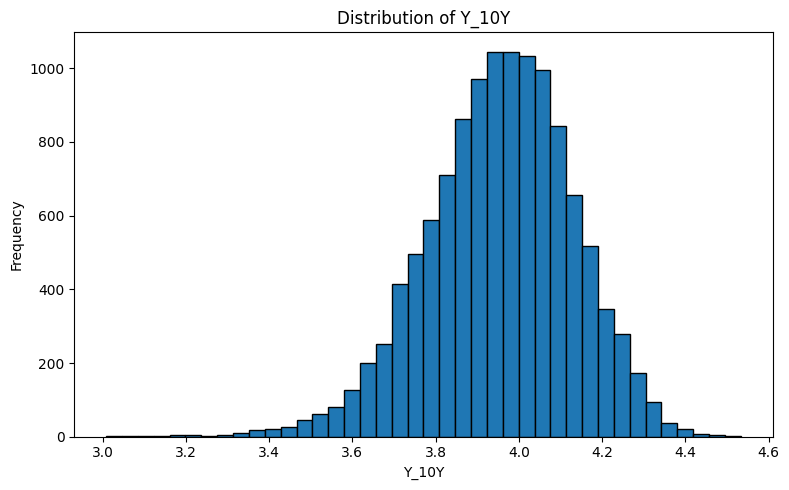

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file (it's CSV-formatted even though the extension is .xls)
df = pd.read_csv("mvp1_simulated_paths.csv")

# Choose the column you want to plot
col = "Y_10Y"   # change this to Y_1M, Y_3M, Y_30Y, etc.

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(df[col].dropna(), bins=40, edgecolor="black")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## first attempt with chatgpt

Generated file: mvp1_simulated_paths.csv
Historical file: ../raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv
Generated curves shape: (200, 60, 11)
Historical curves shape (monthly): (232, 11)
Common tenors: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']


/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:57: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('M').mean(numeric_only=True)
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:111: RuntimeWarning: divide by zero encountered in matmul
  return centered @ components.T
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:111: RuntimeWarning: overflow encountered in matmul
  return centered @ components.T
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:111: RuntimeWarning: invalid value encountered in matmul
  return centered @ components.T



--- Tenor ACF MAE (mean ACFs) ---
Series  MAE_of_mean_ACF
    1M         0.094735
    3M         0.089672
    6M         0.100145
    1Y         0.129888
    2Y         0.160452
    3Y         0.154935
    5Y         0.123090
    7Y         0.089670
   10Y         0.056035
   20Y         0.038442
   30Y         0.043921
Overall tenor MAE: 0.098271

--- PC ACF MAE (mean ACFs) ---
Series  MAE_of_mean_ACF
   PC1         0.108486
   PC2         0.125988
   PC3         0.051740
Overall PC MAE: 0.095405


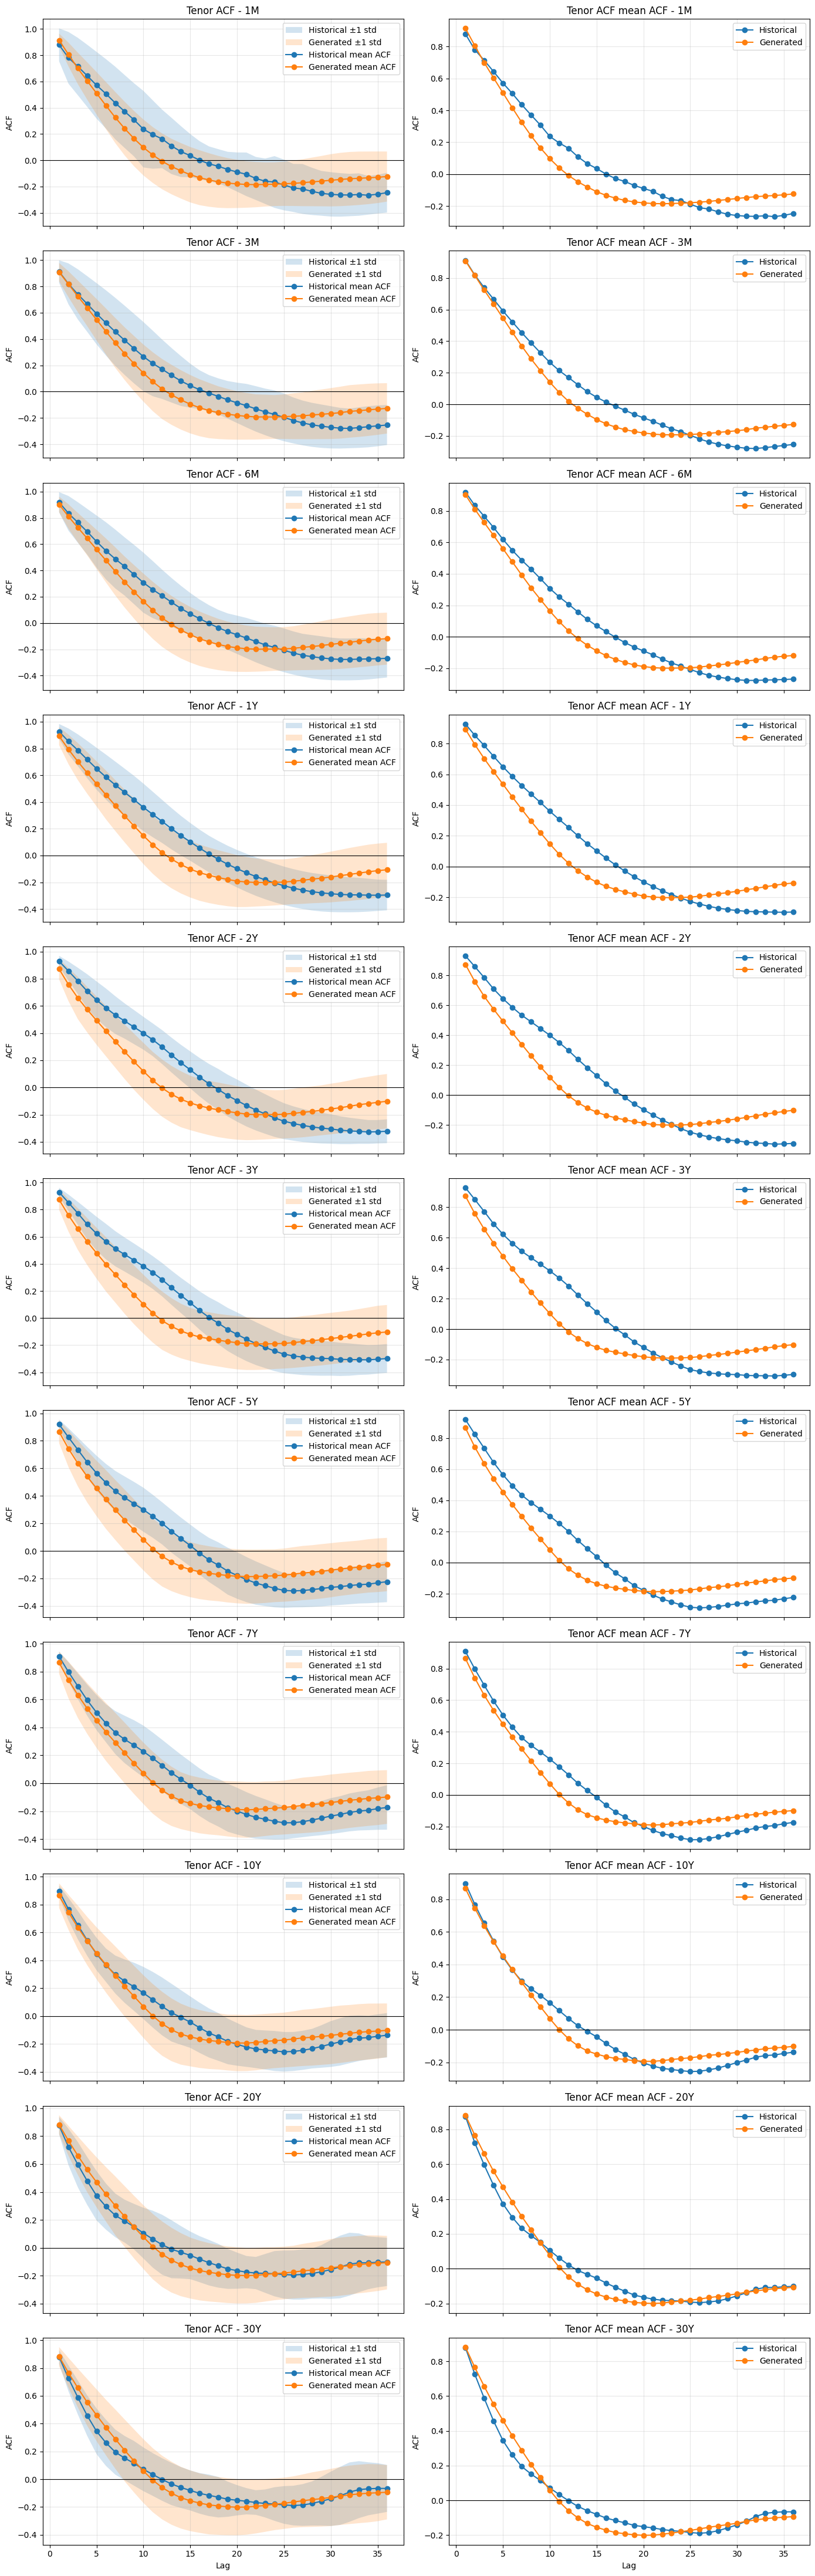

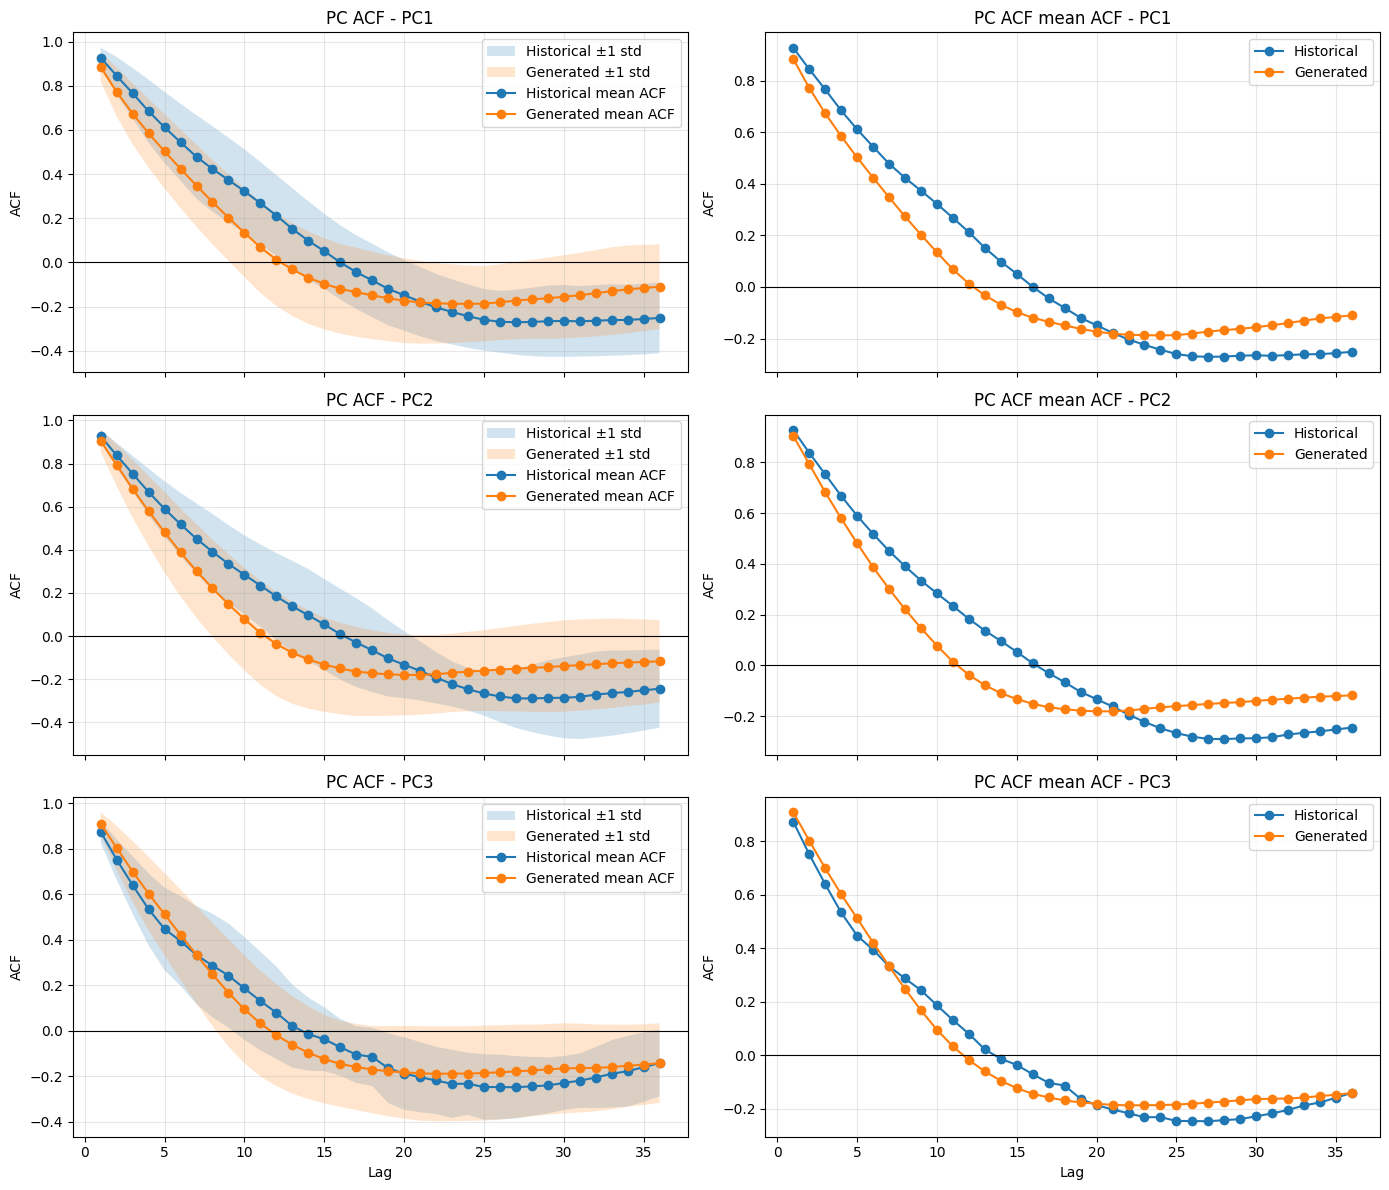

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# ACF comparison: historical vs generated yield curves
# - Historical file is daily -> convert to monthly
# - Generated file is already monthly scenarios
# - Tenors are aligned by name before PCA/ACF
# =========================================================

MAX_LAG = 36
N_PCS = 3
TARGET_WINDOW = 60   # 5 years of monthly data


def resolve_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these files exist: {candidates}")


def tenor_key(column_name):
    if column_name.startswith('Yield_'):
        return column_name.replace('Yield_', '')
    if column_name.startswith('Y_'):
        return column_name.replace('Y_', '')
    return column_name


def load_generated_paths(file_path):
    df = pd.read_csv(file_path)
    meta_cols = [c for c in ['Scenario_ID', 'Month'] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]

    scenario_arrays = []
    if len(meta_cols) == 2:
        df = df.sort_values(meta_cols)
        for _, grp in df.groupby('Scenario_ID'):
            grp = grp.sort_values('Month')
            scenario_arrays.append(grp[value_cols].to_numpy(dtype=float))
    else:
        scenario_arrays.append(df[value_cols].to_numpy(dtype=float))

    return np.stack(scenario_arrays, axis=0), value_cols, df


def load_historical_paths(file_path):
    df = pd.read_csv(file_path)

    if 'DATE' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE'])
        df = df.set_index('DATE')
        df = df.resample('M').mean(numeric_only=True)
    else:
        if 'DATE' in df.columns:
            df = df.drop(columns=['DATE'])

    yield_cols = [c for c in df.columns if c.startswith('Yield_')]
    if len(yield_cols) == 0:
        raise ValueError("No historical yield columns found that start with 'Yield_'.")

    return df[yield_cols].to_numpy(dtype=float), yield_cols, df


def align_tenors(historical_matrix, historical_cols, generated_matrix, generated_cols):
    hist_map = {tenor_key(col): idx for idx, col in enumerate(historical_cols)}
    gen_map = {tenor_key(col): idx for idx, col in enumerate(generated_cols)}
    common = [t for t in ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
              if t in hist_map and t in gen_map]
    if len(common) == 0:
        raise ValueError('No common tenors found between historical and generated files.')

    hist_idx = [hist_map[t] for t in common]
    gen_idx = [gen_map[t] for t in common]

    return historical_matrix[:, hist_idx], generated_matrix[:, :, gen_idx], common


def rolling_windows(array_2d, window):
    return [array_2d[start:start + window] for start in range(0, len(array_2d) - window + 1)]


def acf_1d(series, max_lag=12):
    series = np.asarray(series, dtype=float)
    series = series - np.mean(series)
    denom = np.sum(series ** 2)
    acf_values = np.full(max_lag, np.nan, dtype=float)
    if denom <= 0:
        return acf_values
    for lag in range(1, max_lag + 1):
        if lag >= len(series):
            break
        acf_values[lag - 1] = np.sum(series[:-lag] * series[lag:]) / denom
    return acf_values


def fit_pca_basis(historical_curves, n_components=3):
    mean_curve = historical_curves.mean(axis=0)
    centered = historical_curves - mean_curve
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:n_components]
    return mean_curve, components


def project_to_pcs(curve_matrix, mean_curve, components):
    centered = curve_matrix - mean_curve
    return centered @ components.T


def compute_window_acf(windows, max_lag=12):
    feature_count = windows[0].shape[1]
    acfs = np.full((len(windows), feature_count, max_lag), np.nan, dtype=float)
    for i, window_data in enumerate(windows):
        for j in range(feature_count):
            acfs[i, j] = acf_1d(window_data[:, j], max_lag=max_lag)
    return acfs


def summarise_acf(acf_cube):
    return np.nanmean(acf_cube, axis=0), np.nanstd(acf_cube, axis=0)


def plot_acf_comparison(mean_hist, std_hist, mean_gen, std_gen, labels, title_prefix):
    max_lag = mean_hist.shape[-1]
    lags = np.arange(1, max_lag + 1)
    n_series = mean_hist.shape[0]

    fig, axes = plt.subplots(n_series, 2, figsize=(14, 4 * n_series), sharex='col')
    if n_series == 1:
        axes = np.array([axes])

    for i in range(n_series):
        ax_dist = axes[i, 0]
        ax_mean = axes[i, 1]

        ax_dist.fill_between(lags, mean_hist[i] - std_hist[i], mean_hist[i] + std_hist[i], alpha=0.2, label='Historical ±1 std')
        ax_dist.fill_between(lags, mean_gen[i] - std_gen[i], mean_gen[i] + std_gen[i], alpha=0.2, label='Generated ±1 std')
        ax_dist.plot(lags, mean_hist[i], marker='o', label='Historical mean ACF')
        ax_dist.plot(lags, mean_gen[i], marker='o', label='Generated mean ACF')
        ax_dist.axhline(0, color='black', linewidth=0.8)
        ax_dist.set_title(f'{title_prefix} - {labels[i]}')
        ax_dist.set_ylabel('ACF')
        ax_dist.legend()
        ax_dist.grid(alpha=0.3)

        ax_mean.plot(lags, mean_hist[i], marker='o', label='Historical')
        ax_mean.plot(lags, mean_gen[i], marker='o', label='Generated')
        ax_mean.axhline(0, color='black', linewidth=0.8)
        ax_mean.set_title(f'{title_prefix} mean ACF - {labels[i]}')
        ax_mean.set_ylabel('ACF')
        ax_mean.legend()
        ax_mean.grid(alpha=0.3)

    axes[-1, 0].set_xlabel('Lag')
    axes[-1, 1].set_xlabel('Lag')
    plt.tight_layout()
    plt.show()


def compare_mean_acf_mae(mean_hist, mean_gen, labels):
    per_series_mae = np.mean(np.abs(mean_hist - mean_gen), axis=1)
    overall_mae = np.mean(per_series_mae)
    return pd.DataFrame({'Series': labels, 'MAE_of_mean_ACF': per_series_mae}), overall_mae


# -----------------------------
# Load files
# -----------------------------
generated_path = resolve_existing_path([
    'mvp1_simulated_paths.csv',
    'testing/mvp1_simulated_paths.csv',
])
historical_path = resolve_existing_path([
    'raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv',
    '../raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv',
    'testing/raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv',
])

print('Generated file:', generated_path)
print('Historical file:', historical_path)

generated_curves, generated_yield_cols, generated_df = load_generated_paths(generated_path)
historical_curves, historical_yield_cols, historical_df = load_historical_paths(historical_path)

historical_curves, generated_curves, common_tenors = align_tenors(
    historical_curves,
    historical_yield_cols,
    generated_curves,
    generated_yield_cols,
)

generated_yield_cols = [f'Y_{t}' for t in common_tenors]
historical_yield_cols = [f'Yield_{t}' for t in common_tenors]

print('Generated curves shape:', generated_curves.shape)
print('Historical curves shape (monthly):', historical_curves.shape)
print('Common tenors:', common_tenors)

# -----------------------------
# Window choice
# -----------------------------
# Exact figure-style comparison needs 60-month generated scenarios.
# Your current generated file has 12 months per scenario, so we fall back to the largest common window.
window = min(TARGET_WINDOW, historical_curves.shape[0], generated_curves.shape[1])
if window < TARGET_WINDOW:
    print(f'Warning: using WINDOW={window} because the generated scenarios are only {generated_curves.shape[1]} months long.')
    print('To do the exact 5-year window analysis from the figure, you need generated paths with at least 60 months.')

# -----------------------------
# Tenor ACF
# -----------------------------
tenor_hist_windows = rolling_windows(historical_curves, window)
tenor_gen_windows = [scenario for scenario in generated_curves if len(scenario) >= window]

if len(tenor_gen_windows) == 0:
    raise ValueError('No generated scenarios are long enough for the selected window.')

hist_tenor_acf = compute_window_acf(tenor_hist_windows, max_lag=MAX_LAG)
gen_tenor_acf = compute_window_acf(tenor_gen_windows, max_lag=MAX_LAG)

mean_hist_tenor_acf, std_hist_tenor_acf = summarise_acf(hist_tenor_acf)
mean_gen_tenor_acf, std_gen_tenor_acf = summarise_acf(gen_tenor_acf)

# -----------------------------
# PCA factors (1, 2, 3)
# -----------------------------
mean_curve, pca_components = fit_pca_basis(historical_curves, n_components=N_PCS)

historical_pc_scores = project_to_pcs(historical_curves, mean_curve, pca_components)
generated_pc_scores = [project_to_pcs(scenario, mean_curve, pca_components) for scenario in generated_curves]

pc_hist_windows = rolling_windows(historical_pc_scores, window)
pc_gen_windows = [scores for scores in generated_pc_scores if len(scores) >= window]

hist_pc_acf = compute_window_acf(pc_hist_windows, max_lag=MAX_LAG)
gen_pc_acf = compute_window_acf(pc_gen_windows, max_lag=MAX_LAG)

mean_hist_pc_acf, std_hist_pc_acf = summarise_acf(hist_pc_acf)
mean_gen_pc_acf, std_gen_pc_acf = summarise_acf(gen_pc_acf)

# -----------------------------
# MAE of mean ACFs
# -----------------------------
tenor_mae_df, tenor_overall_mae = compare_mean_acf_mae(mean_hist_tenor_acf, mean_gen_tenor_acf, common_tenors)
pc_labels = [f'PC{i}' for i in range(1, N_PCS + 1)]
pc_mae_df, pc_overall_mae = compare_mean_acf_mae(mean_hist_pc_acf, mean_gen_pc_acf, pc_labels)

print('\n--- Tenor ACF MAE (mean ACFs) ---')
print(tenor_mae_df.to_string(index=False))
print(f'Overall tenor MAE: {tenor_overall_mae:.6f}')

print('\n--- PC ACF MAE (mean ACFs) ---')
print(pc_mae_df.to_string(index=False))
print(f'Overall PC MAE: {pc_overall_mae:.6f}')

# -----------------------------
# Plots
# -----------------------------
plot_acf_comparison(
    mean_hist_tenor_acf,
    std_hist_tenor_acf,
    mean_gen_tenor_acf,
    std_gen_tenor_acf,
    common_tenors,
    title_prefix='Tenor ACF'
)

plot_acf_comparison(
    mean_hist_pc_acf,
    std_hist_pc_acf,
    mean_gen_pc_acf,
    std_gen_pc_acf,
    pc_labels,
    title_prefix='PC ACF'
)

# Optional save
# tenor_mae_df.to_csv('tenor_acf_mae.csv', index=False)
# pc_mae_df.to_csv('pc_acf_mae.csv', index=False)


/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:111: RuntimeWarning: divide by zero encountered in matmul
  return centered @ components.T
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:111: RuntimeWarning: overflow encountered in matmul
  return centered @ components.T
/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/4179807311.py:111: RuntimeWarning: invalid value encountered in matmul
  return centered @ components.T



--- Tenor ACF MAE (CHANGES) ---
Series  MAE_of_mean_ACF
    1M         0.071358
    3M         0.048267
    6M         0.050882
    1Y         0.054270
    2Y         0.058458
    3Y         0.059199
    5Y         0.053568
    7Y         0.048928
   10Y         0.043138
   20Y         0.036039
   30Y         0.035461
Overall tenor MAE (changes): 0.050870

--- PC ACF MAE (CHANGES) ---
Series  MAE_of_mean_ACF
   PC1         0.053776
   PC2         0.053049
   PC3         0.058858
Overall PC MAE (changes): 0.055228


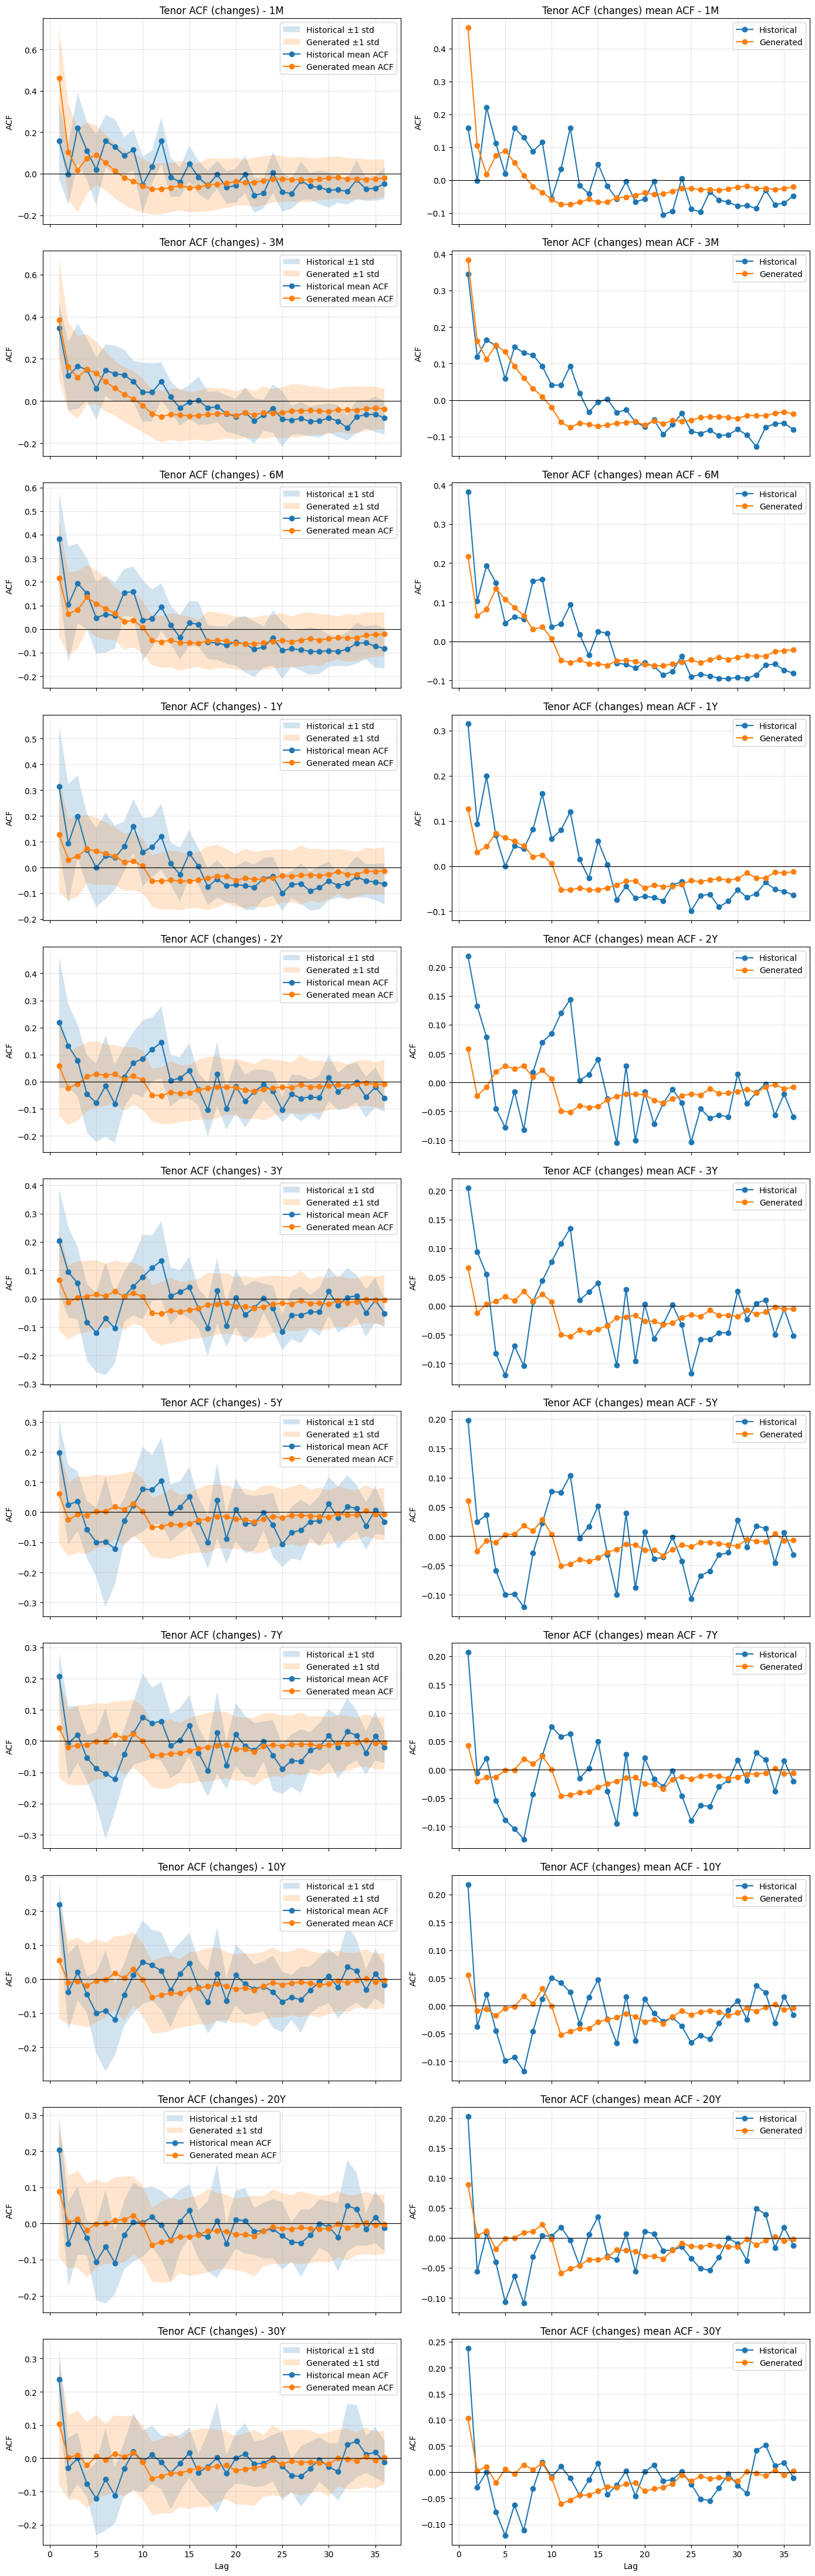

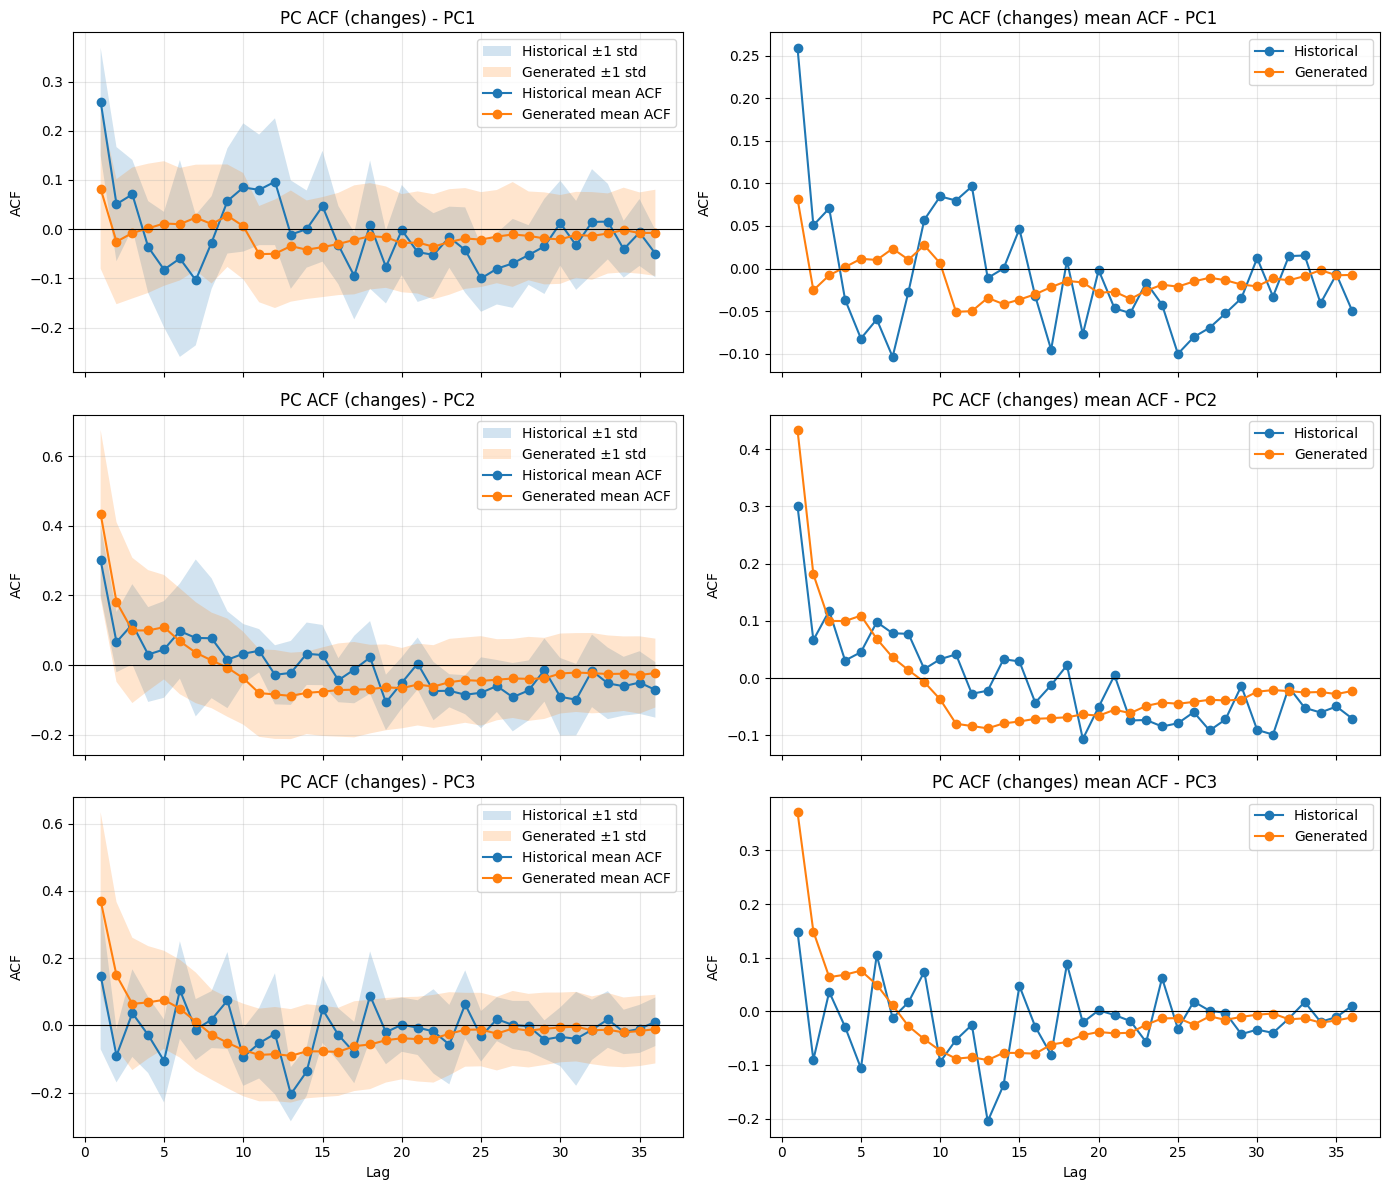

In [18]:
# =========================================================
# ACF on CHANGES (first differences) - separate block
# =========================================================

# Requires previous cell to be run first (functions + aligned data)
historical_changes = np.diff(historical_curves, axis=0)
generated_changes = np.diff(generated_curves, axis=1)

window_chg = min(TARGET_WINDOW, historical_changes.shape[0], generated_changes.shape[1])
if window_chg < TARGET_WINDOW:
    print(f'Warning: using WINDOW={window_chg} for changes (generated scenarios are too short for 60 months).')

# -----------------------------
# Tenor ACF (changes)
# -----------------------------
tenor_hist_windows_chg = rolling_windows(historical_changes, window_chg)
tenor_gen_windows_chg = [scenario for scenario in generated_changes if len(scenario) >= window_chg]

if len(tenor_gen_windows_chg) == 0:
    raise ValueError('No generated scenarios are long enough for the selected changes window.')

hist_tenor_acf_chg = compute_window_acf(tenor_hist_windows_chg, max_lag=MAX_LAG)
gen_tenor_acf_chg = compute_window_acf(tenor_gen_windows_chg, max_lag=MAX_LAG)

mean_hist_tenor_acf_chg, std_hist_tenor_acf_chg = summarise_acf(hist_tenor_acf_chg)
mean_gen_tenor_acf_chg, std_gen_tenor_acf_chg = summarise_acf(gen_tenor_acf_chg)

# -----------------------------
# PCA factors (changes)
# -----------------------------
mean_curve_chg, pca_components_chg = fit_pca_basis(historical_changes, n_components=N_PCS)

historical_pc_scores_chg = project_to_pcs(historical_changes, mean_curve_chg, pca_components_chg)
generated_pc_scores_chg = [project_to_pcs(scenario, mean_curve_chg, pca_components_chg) for scenario in generated_changes]

pc_hist_windows_chg = rolling_windows(historical_pc_scores_chg, window_chg)
pc_gen_windows_chg = [scores for scores in generated_pc_scores_chg if len(scores) >= window_chg]

hist_pc_acf_chg = compute_window_acf(pc_hist_windows_chg, max_lag=MAX_LAG)
gen_pc_acf_chg = compute_window_acf(pc_gen_windows_chg, max_lag=MAX_LAG)

mean_hist_pc_acf_chg, std_hist_pc_acf_chg = summarise_acf(hist_pc_acf_chg)
mean_gen_pc_acf_chg, std_gen_pc_acf_chg = summarise_acf(gen_pc_acf_chg)

# -----------------------------
# MAE of mean ACFs (changes)
# -----------------------------
tenor_mae_df_chg, tenor_overall_mae_chg = compare_mean_acf_mae(mean_hist_tenor_acf_chg, mean_gen_tenor_acf_chg, common_tenors)
pc_labels = [f'PC{i}' for i in range(1, N_PCS + 1)]
pc_mae_df_chg, pc_overall_mae_chg = compare_mean_acf_mae(mean_hist_pc_acf_chg, mean_gen_pc_acf_chg, pc_labels)

print('\n--- Tenor ACF MAE (CHANGES) ---')
print(tenor_mae_df_chg.to_string(index=False))
print(f'Overall tenor MAE (changes): {tenor_overall_mae_chg:.6f}')

print('\n--- PC ACF MAE (CHANGES) ---')
print(pc_mae_df_chg.to_string(index=False))
print(f'Overall PC MAE (changes): {pc_overall_mae_chg:.6f}')

# -----------------------------
# Plots (changes)
# -----------------------------
plot_acf_comparison(
    mean_hist_tenor_acf_chg,
    std_hist_tenor_acf_chg,
    mean_gen_tenor_acf_chg,
    std_gen_tenor_acf_chg,
    common_tenors,
    title_prefix='Tenor ACF (changes)'
)

plot_acf_comparison(
    mean_hist_pc_acf_chg,
    std_hist_pc_acf_chg,
    mean_gen_pc_acf_chg,
    std_gen_pc_acf_chg,
    pc_labels,
    title_prefix='PC ACF (changes)'
)



--- Level ACF MAE (SELECTED MATURITIES) ---
Series  MAE_of_mean_ACF
    1M         0.094735
    6M         0.100145
    1Y         0.129888
    2Y         0.160452
    5Y         0.123090
   10Y         0.056035
   20Y         0.038442
   30Y         0.043921
Overall selected-tenor MAE: 0.093338


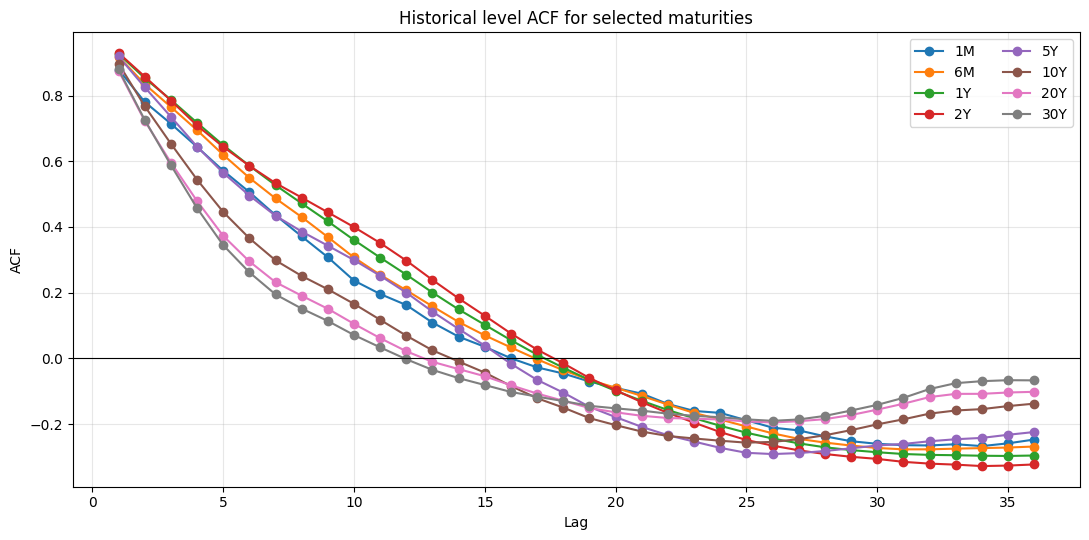

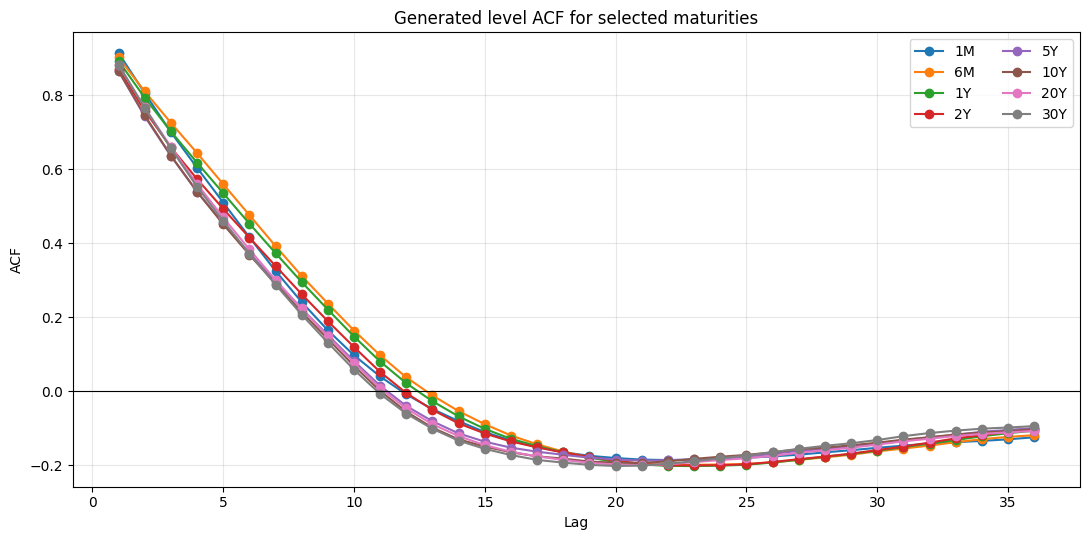

In [23]:
# =========================================================
# LEVEL ACF: separate plots for historical and generated
# =========================================================

# Requires previous cell to be run first (functions + aligned data)
selected_tenors = ['1M', '6M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']

# Keep only tenors available in the current aligned data
selected_tenors = [tenor for tenor in selected_tenors if tenor in common_tenors]

selected_idx = [common_tenors.index(tenor) for tenor in selected_tenors]
hist_selected = historical_curves[:, selected_idx]
gen_selected = generated_curves[:, :, selected_idx]

window_sel = min(TARGET_WINDOW, hist_selected.shape[0], gen_selected.shape[1])
if window_sel < TARGET_WINDOW:
    print(f'Warning: using WINDOW={window_sel} because generated scenarios are shorter than 60 months.')

hist_windows_sel = rolling_windows(hist_selected, window_sel)
gen_windows_sel = [scenario for scenario in gen_selected if len(scenario) >= window_sel]

if len(gen_windows_sel) == 0:
    raise ValueError('No generated scenarios are long enough for the selected window.')

hist_acf_sel = compute_window_acf(hist_windows_sel, max_lag=MAX_LAG)
gen_acf_sel = compute_window_acf(gen_windows_sel, max_lag=MAX_LAG)

mean_hist_acf_sel, std_hist_acf_sel = summarise_acf(hist_acf_sel)
mean_gen_acf_sel, std_gen_acf_sel = summarise_acf(gen_acf_sel)

mae_df_sel, overall_mae_sel = compare_mean_acf_mae(mean_hist_acf_sel, mean_gen_acf_sel, selected_tenors)

print('\n--- Level ACF MAE (SELECTED MATURITIES) ---')
print(mae_df_sel.to_string(index=False))
print(f'Overall selected-tenor MAE: {overall_mae_sel:.6f}')

lags = np.arange(1, MAX_LAG + 1)

# Separate plot 1: historical
plt.figure(figsize=(11, 5.5))
for i, tenor in enumerate(selected_tenors):
    plt.plot(lags, mean_hist_acf_sel[i], marker='o', label=tenor)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Historical level ACF for selected maturities')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Separate plot 2: generated
plt.figure(figsize=(11, 5.5))
for i, tenor in enumerate(selected_tenors):
    plt.plot(lags, mean_gen_acf_sel[i], marker='o', label=tenor)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Generated level ACF for selected maturities')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Using historical file: ../raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv

ACF (full historical, all maturities):
            lag_1   lag_2   lag_3   lag_4   lag_5   lag_6   lag_7   lag_8   lag_9  lag_10  lag_11  lag_12  lag_13  lag_14  lag_15  lag_16  lag_17  lag_18  lag_19  lag_20
Yield_1M   0.9901  0.9758  0.9605  0.9401  0.9169  0.8929  0.8641  0.8307  0.7947  0.7549  0.7144  0.6723  0.6273  0.5829  0.5414  0.4981  0.4551  0.4133  0.3715  0.3319
Yield_3M   0.9917  0.9784  0.9623  0.9429  0.9208  0.8965  0.8692  0.8381  0.8040  0.7671  0.7284  0.6875  0.6449  0.6015  0.5603  0.5183  0.4763  0.4351  0.3942  0.3546
Yield_6M   0.9925  0.9795  0.9629  0.9439  0.9225  0.8990  0.8735  0.8456  0.8148  0.7807  0.7444  0.7058  0.6658  0.6247  0.5854  0.5453  0.5048  0.4646  0.4249  0.3863
Yield_1Y   0.9916  0.9772  0.9592  0.9390  0.9174  0.8946  0.8705  0.8447  0.8166  0.7851  0.7513  0.7149  0.6772  0.6386  0.6018  0.5642  0.5261  0.4882  0.4509  0.4143
Yield_2Y   0.9872  0.9

/var/folders/x3/05_l03tx04300w71f1fld59c0000gn/T/ipykernel_93418/3640344679.py:49: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_hist = df_hist.set_index('DATE').resample('M').mean(numeric_only=True)


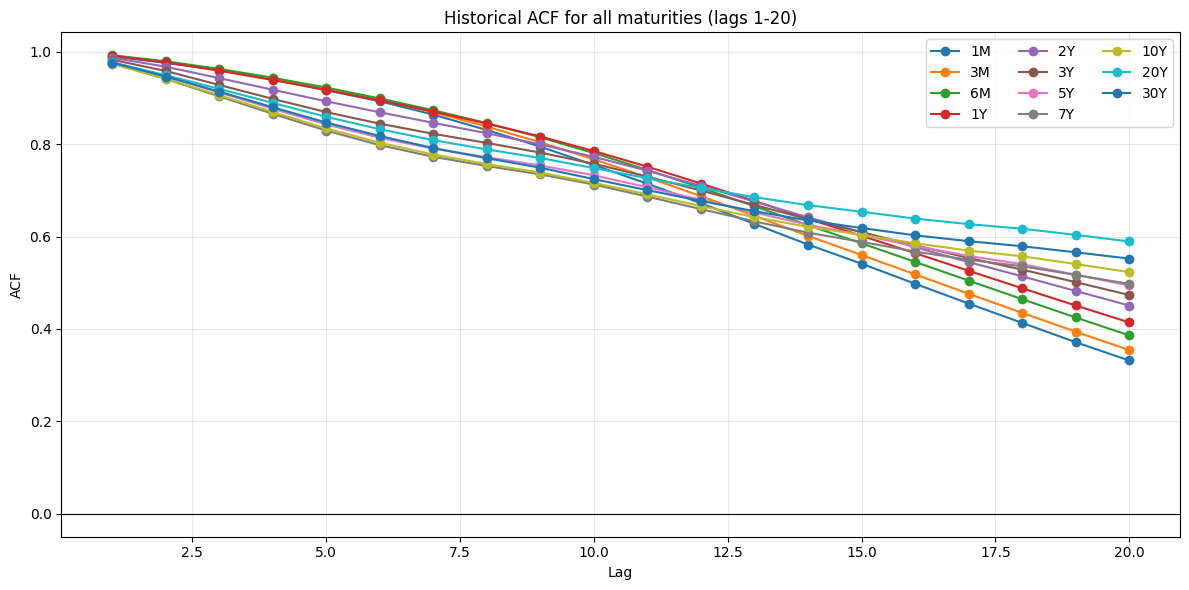

In [26]:
# =========================================================
# INDEPENDENT BLOCK: ACF for all maturities (historical only)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MAX_LAG_HIST_ALL = 20


def acf_1d_local(series, max_lag=36):
    series = np.asarray(series, dtype=float)
    series = series - np.mean(series)
    denom = np.sum(series ** 2)
    out = np.full(max_lag, np.nan, dtype=float)
    if denom <= 0:
        return out
    for lag in range(1, max_lag + 1):
        if lag >= len(series):
            break
        out[lag - 1] = np.sum(series[:-lag] * series[lag:]) / denom
    return out


# Resolve historical file path independently
candidates = [
    'raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv',
    '../raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv',
    'testing/raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv',
]

hist_path = None
for c in candidates:
    p = Path(c)
    if p.exists():
        hist_path = p
        break
if hist_path is None:
    raise FileNotFoundError(f'Historical file not found. Tried: {candidates}')

print('Using historical file:', hist_path)

# Load and convert to monthly
df_hist = pd.read_csv(hist_path)
if 'DATE' in df_hist.columns:
    df_hist['DATE'] = pd.to_datetime(df_hist['DATE'])
    df_hist = df_hist.set_index('DATE').resample('M').mean(numeric_only=True)

# Keep all maturity columns
yield_cols = [c for c in df_hist.columns if c.startswith('Yield_')]
if len(yield_cols) == 0:
    raise ValueError("No maturity columns found (expected prefix 'Yield_').")

hist_mat = df_hist[yield_cols].to_numpy(dtype=float)

# ACF per maturity on full historical dataset
acf_all = np.vstack([acf_1d_local(hist_mat[:, i], max_lag=MAX_LAG_HIST_ALL) for i in range(hist_mat.shape[1])])

# Table
acf_all_df = pd.DataFrame(
    acf_all,
    index=yield_cols,
    columns=[f'lag_{k}' for k in range(1, MAX_LAG_HIST_ALL + 1)]
)
print('\nACF (full historical, all maturities):')
print(acf_all_df.round(4).to_string())

# Plot all maturities on one chart
lags = np.arange(1, MAX_LAG_HIST_ALL + 1)
plt.figure(figsize=(12, 6))
for i, col in enumerate(yield_cols):
    plt.plot(lags, acf_all[i], marker='o', label=col.replace('Yield_', ''))

plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Historical ACF for all maturities (lags 1-{MAX_LAG_HIST_ALL})')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


### volatility